In [77]:
!pip install --upgrade pip
!pip install kagglehub 
!pip install  wordcloud


In [37]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ymanojkumar023/kumarmanoj-bag-of-words-meets-bags-of-popcorn")

print("Path to dataset files:", path)

Path to dataset files: /Users/anuragpanchal/.cache/kagglehub/datasets/ymanojkumar023/kumarmanoj-bag-of-words-meets-bags-of-popcorn/versions/1


In [38]:
!pip install pandas matplotlib seaborn scikit-learn tensorflow keras


In [39]:
import pandas as pd 
import os

In [40]:
os.listdir(path)

['sampleSubmission.csv',
 'labeledTrainData.tsv',
 'testData.tsv',
 'unlabeledTrainData.tsv']

In [41]:
df  = pd.read_csv(path+'/labeledTrainData.tsv',delimiter='\t')

In [42]:
df['review'][0]

"With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.<br /><br />Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.<br /><br />The actual feature film bit when it finally sta

In [43]:
!pip install nltk beautifulsoup4

In [44]:
import re 
import nltk 
from bs4 import BeautifulSoup

In [45]:
nltk.download("all")

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     /Users/anuragpanchal/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     /Users/anuragpanchal/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /Users/anuragpanchal/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /Users/anuragpanchal/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /Users/anuragpanchal/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagg

True

In [46]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [47]:
stopwords =stopwords.words('english')
wordnet_lemm = WordNetLemmatizer()

In [48]:
review = df['review'][0]

In [49]:
def preprocessing_text(review):   
    #remove all html texs
    review = BeautifulSoup(review).get_text()
    #removing anything which is not character 
    review = re.sub("[^a-zA-Z]"," ",review)
    #lowercase 
    review = review.lower()
    #stopword
    review = " ".join(i for i in review.split() if i not in stopwords)
    #lematizer
    review = " ".join([wordnet_lemm.lemmatize(i) for i in review.split()])
    #Tokenization ->Sentence to a list of words
    return review

In [50]:
review

"With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.<br /><br />Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.<br /><br />The actual feature film bit when it finally sta

In [51]:
review = df['review'][1]
print("Original text:")
print(review)
print("-"*25)
cleaned_reviw = preprocessing_text(review)
print("Cleaned Text:")
print(cleaned_reviw)


Original text:
\The Classic War of the Worlds\" by Timothy Hines is a very entertaining film that obviously goes to great effort and lengths to faithfully recreate H. G. Wells' classic book. Mr. Hines succeeds in doing so. I, and those who watched his film with me, appreciated the fact that it was not the standard, predictable Hollywood fare that comes out every year, e.g. the Spielberg version with Tom Cruise that had only the slightest resemblance to the book. Obviously, everyone looks for different things in a movie. Those who envision themselves as amateur \"critics\" look only to criticize everything they can. Others rate a movie on more important bases,like being entertained, which is why most people never agree with the \"critics\". We enjoyed the effort Mr. Hines put into being faithful to H.G. Wells' classic novel, and we found it to be very entertaining. This made it easy to overlook what the \"critics\" perceive to be its shortcomings."
-------------------------
Cleaned Text

In [52]:
df['cleand_review'] = df['review'].apply(preprocessing_text)

In [53]:
#list all the words frequency 
freq_list = {}
for review in df['cleand_review'].tolist():
    for word in review.split():
        freq_list[word] =freq_list.get(word,0)+1

In [ ]:
freq_list

{'stuff': 1181,
 'going': 4146,
 'moment': 2775,
 'mj': 35,
 'started': 963,
 'listening': 189,
 'music': 3061,
 'watching': 4605,
 'odd': 582,
 'documentary': 1074,
 'watched': 2236,
 'wiz': 11,
 'moonwalker': 24,
 'maybe': 2340,
 'want': 4990,
 'get': 12514,
 'certain': 764,
 'insight': 250,
 'guy': 4339,
 'thought': 3656,
 'really': 11736,
 'cool': 971,
 'eighty': 127,
 'make': 12225,
 'mind': 2180,
 'whether': 856,
 'guilty': 198,
 'innocent': 434,
 'part': 5233,
 'biography': 99,
 'feature': 1434,
 'film': 47034,
 'remember': 1702,
 'see': 12012,
 'cinema': 1553,
 'originally': 290,
 'released': 986,
 'subtle': 434,
 'message': 960,
 'feeling': 1540,
 'towards': 637,
 'press': 134,
 'also': 9156,
 'obvious': 1066,
 'drug': 728,
 'bad': 9302,
 'kay': 91,
 'visually': 259,
 'impressive': 500,
 'course': 2517,
 'michael': 1370,
 'jackson': 346,
 'unless': 675,
 'remotely': 189,
 'like': 20740,
 'anyway': 1117,
 'hate': 893,
 'find': 5079,
 'boring': 1809,
 'may': 3392,
 'call': 1183,

In [58]:
sorted_freq_words = dict(sorted(freq_list.items(),key=lambda item:item[1],reverse=True))

In [59]:
sorted_freq_words

{'movie': 51694,
 'film': 47034,
 'one': 27741,
 'like': 20740,
 'time': 15959,
 'good': 15197,
 'character': 14177,
 'story': 13165,
 'even': 12646,
 'get': 12514,
 'would': 12436,
 'make': 12225,
 'see': 12012,
 'really': 11736,
 'well': 10783,
 'scene': 10585,
 'much': 9765,
 'people': 9385,
 'bad': 9302,
 'also': 9156,
 'great': 9088,
 'first': 9062,
 'way': 8830,
 'show': 8603,
 'made': 8362,
 'thing': 8214,
 'life': 8032,
 'could': 7922,
 'think': 7733,
 'go': 7600,
 'watch': 7095,
 'know': 7067,
 'two': 6908,
 'year': 6878,
 'actor': 6875,
 'plot': 6870,
 'love': 6858,
 'seen': 6679,
 'many': 6675,
 'end': 6632,
 'look': 6558,
 'say': 6505,
 'acting': 6491,
 'never': 6484,
 'little': 6435,
 'best': 6420,
 'man': 6019,
 'ever': 5995,
 'better': 5739,
 'take': 5699,
 'come': 5673,
 'still': 5655,
 'work': 5650,
 'part': 5233,
 'director': 5119,
 'find': 5079,
 'something': 5077,
 'back': 5045,
 'want': 4990,
 'give': 4952,
 'lot': 4778,
 'real': 4738,
 'performance': 4717,
 'woman

In [60]:
from collections import Counter
cnt =Counter(" ".join(df['cleand_review'].tolist()).split())

In [63]:
cnt.most_common(10)

[('movie', 51694),
 ('film', 47034),
 ('one', 27741),
 ('like', 20740),
 ('time', 15959),
 ('good', 15197),
 ('character', 14177),
 ('story', 13165),
 ('even', 12646),
 ('get', 12514)]

In [69]:
pos_cnt = Counter(" ".join(df.loc[df['sentiment']==1]['cleand_review'].to_list()).split())
neg_cnt = Counter(" ".join(df.loc[df['sentiment']==0]['cleand_review'].to_list()).split())

In [70]:
pos_cnt.most_common(10)

[('film', 24745),
 ('movie', 22657),
 ('one', 14169),
 ('like', 9270),
 ('time', 8346),
 ('good', 7762),
 ('story', 7478),
 ('character', 7073),
 ('well', 6488),
 ('great', 6435)]

In [72]:
neg_cnt.most_common(10)

[('movie', 29037),
 ('film', 22289),
 ('one', 13572),
 ('like', 11470),
 ('even', 7684),
 ('time', 7613),
 ('good', 7435),
 ('bad', 7394),
 ('character', 7104),
 ('would', 7036)]

In [79]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(stopwords=["film","movie"],width=800, height=400, background_color='white').generate(" ".join(df['cleand_review'].tolist()))

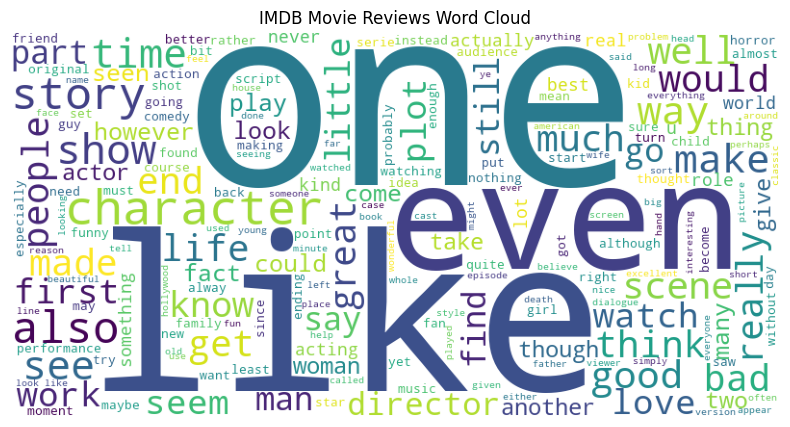

In [80]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')  
plt.title("IMDB Movie Reviews Word Cloud")
plt.show()

In [81]:
import numpy as np 

In [82]:
from PIL import Image
upvote_mask = np.array(Image.open("/kaggle/input/datasets/aayushkubba/mask-image/upvote.png"))

wordcloud = WordCloud(stopwords=["film","movie"],width=800, height=400, mask=upvote_mask,background_color='white').generate(" ".join(df['cleand_review'].tolist()))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')  
plt.title("IMDB Movie Reviews Word Cloud")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/aayushkubba/mask-image/upvote.png'